In [1]:
import pandas as pd
import os
import numpy as np
import pickle
from scipy.stats import ttest_rel, ttest_1samp
import matplotlib.pyplot as plt
import SensoriMotorPrediction.globals as gl
from SensoriMotorPrediction.vis import plot_rdm
from SensoriMotorPrediction.force import calc_G_force
from SensoriMotorPrediction.util import upper_noise_ceiling, lower_noise_ceiling
import PcmPy as pcm

Base directory: /cifs/diedrichsen/data/SensoriMotorPrediction/
Atlases dir found: atlases


# Regressing out the pre-activation geometry (Fig. S4)

In [2]:
behav = pd.read_csv(os.path.join('data', 'behavioural', 'behaviour.trial.tsv'), sep='\t')
N = behav.sn.nunique()

## Regressing out the pre-activation geometry (Fig. S4a)

SMA: tval=2.887, pval=0.006
PMd: tval=4.682, pval=0.000
PMv: tval=3.494, pval=0.002
M1: tval=3.975, pval=0.001
S1: tval=4.531, pval=0.000
SPLa: tval=3.977, pval=0.001
SPLp: tval=5.146, pval=0.000


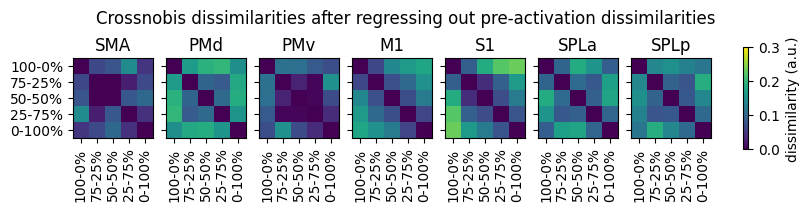

In [3]:
H = 'L'
rois = gl.rois['ROI']
glm = 12

behav_block_cue = behav.groupby(['sn', 'BN', 'cue']).mean(numeric_only=True).reset_index()
G_force, _ = calc_G_force(behav_block_cue, prewhiten=False)
D_force = pcm.G_to_dist(G_force)

fig, axs = plt.subplots(1, len(rois), figsize=(8, 2),sharex=True, sharey=True, constrained_layout=True)
vmin, vmax = 0, .3
D_res = np.zeros((len(rois), N, 5, 5))
for r, roi in enumerate(rois):
    G = np.load(os.path.join('data', 'representation', f'G_obs.plan.glm{glm}.{H}.{roi}.npy'))
    D_bold = pcm.G_to_dist(G)
    D = D_bold.reshape(-1, 25)
    D_res_roi = np.zeros_like(D)
    for i in range(D.shape[0]):
        X = np.c_[np.ones(D.shape[1]), D_force.reshape(-1, 25)[i]]
        W = np.linalg.pinv(X) @ D[i]
        D_hat = X[:, 1] * W[1]
        D_res_roi[i] = D[i] - D_hat
    D_res_roi = D_res_roi.reshape(-1, 5, 5)
    D_res[r] = D_res_roi
    plot_rdm(fig, axs, r, D_res_roi, gl.cues, vmin=vmin, vmax=vmax, sqrt=True, source=roi)
    axs[r].set_title(roi)
cax = axs[-1].get_images()[0]
cbar = fig.colorbar(cax, ax=axs, orientation='vertical', fraction=.008)
cbar.set_label('dissimilarity (a.u.)')
fig.suptitle(f'Crossnobis dissimilarities after regressing out pre-activation dissimilarities')
fig.savefig(os.path.join('figures', 'crossnobis.plan.preactivation_geom_out.pdf'))
plt.show()

## Correlation between representation geometry before and after regressing out pre-activation dissimilarities (Fig. S4b)

SMA, expectation: rho=0.103, t-test against 0: t=1.960, p=0.036; t-test against lower noise ceiling: t=-4.032, p=0.001
SMA, uncertainty: rho=0.315, t-test against 0: t=4.113, p=0.001; t-test against lower noise ceiling: t=-0.018, p=0.493
PMd, expectation: rho=0.164, t-test against 0: t=2.745, p=0.008; t-test against lower noise ceiling: t=-3.087, p=0.004
PMd, uncertainty: rho=0.379, t-test against 0: t=3.560, p=0.002; t-test against lower noise ceiling: t=0.292, p=0.613
PMv, expectation: rho=0.077, t-test against 0: t=0.908, p=0.190; t-test against lower noise ceiling: t=-2.809, p=0.007
PMv, uncertainty: rho=0.315, t-test against 0: t=2.952, p=0.006; t-test against lower noise ceiling: t=-0.001, p=0.500
M1, expectation: rho=0.305, t-test against 0: t=2.970, p=0.005; t-test against lower noise ceiling: t=0.597, p=0.720
M1, uncertainty: rho=0.097, t-test against 0: t=1.341, p=0.101; t-test against lower noise ceiling: t=-2.029, p=0.032
S1, expectation: rho=0.555, t-test against 0: t=8.05

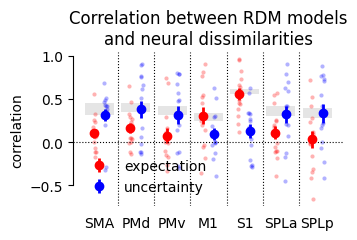

In [4]:
f = open(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, f'M.plan.p'), "rb")
M = pickle.load(f)
Gc = M[3].Gc

mask = np.triu(np.zeros_like(Gc[0]) + 1, k=1).astype(bool)

D_exp = pcm.G_to_dist(Gc[0])[None, mask]
D_unc = pcm.G_to_dist(Gc[1])[None, mask]

corr_exp = np.zeros((len(rois), N))
corr_unc = np.zeros_like(corr_exp)
ceil_upper = np.zeros_like(corr_exp)
ceil_lower = np.zeros_like(corr_exp)
for r, roi in enumerate(rois):
    D = D_res[r][:, mask]
    ceil_upper[r] = upper_noise_ceiling(D)
    ceil_lower[r] = lower_noise_ceiling(D)
    corr_exp[r] = np.corrcoef(np.r_[D_exp, D])[0, 1:]
    corr_unc[r] = np.corrcoef(np.r_[D_unc, D])[0, 1:]

fig, ax = plt.subplots(figsize=(3.5, 2))

width = 0.3
x = np.arange(len(rois))

rng = np.random.default_rng(0)
jitter = 0.05

for n in range(N):
    ax.plot(x - width/2 + rng.uniform(-jitter, jitter, len(rois)), corr_exp[:, n], color='r', alpha=0.3, lw=0, marker='o', ms=3, markeredgecolor='none')
    ax.plot(x + width/2 + rng.uniform(-jitter, jitter, len(rois)), corr_unc[:, n], color='b', alpha=0.3, lw=0, marker='o', ms=3, markeredgecolor='none')

ax.errorbar(x - width/2, corr_exp.mean(axis=1), yerr=corr_exp.std(axis=1) / np.sqrt(N), color='r', label='expectation', lw=2, ls='none', marker='o')
ax.errorbar(x + width/2, corr_unc.mean(axis=1), yerr=corr_unc.std(axis=1) / np.sqrt(N), color='b', label='uncertainty', lw=2, ls='none', marker='o')
ax.set_xticks(x)
ax.set_xticklabels(rois)
ax.legend(frameon=False)

ceil_lower_mean = ceil_lower.mean(axis=1)
ceil_upper_mean = ceil_upper.mean(axis=1)

sep = [.5, 1.5, 2.5, 3.5, 4.5, 5.5]

for s in sep:
    ax.axvline(s, lw=.8, ls=':', color='k')

bar_width = 0.8
for r, roi in enumerate(rois):
    ttest_dep_exp = ttest_rel(corr_exp[r], ceil_lower[r], alternative='less')
    ttest_one_exp = ttest_1samp(corr_exp[r], 0, alternative='greater')
    ttest_dep_unc = ttest_rel(corr_unc[r], ceil_lower[r], alternative='less')
    ttest_one_unc = ttest_1samp(corr_unc[r], 0, alternative='greater')
    print(f'{roi}, expectation: rho={corr_exp.mean(axis=1)[r]:.03f}, t-test against 0: t={ttest_one_exp.statistic:.03f}, p={ttest_one_exp.pvalue:.03f}; t-test against lower noise ceiling: t={ttest_dep_exp.statistic:.03f}, p={ttest_dep_exp.pvalue:.03f}')
    print(f'{roi}, uncertainty: rho={corr_unc.mean(axis=1)[r]:.03f}, t-test against 0: t={ttest_one_unc.statistic:.03f}, p={ttest_one_unc.pvalue:.03f}; t-test against lower noise ceiling: t={ttest_dep_unc.statistic:.03f}, p={ttest_dep_unc.pvalue:.03f}')
    ax.fill_between(
        [r - bar_width / 2, r + bar_width / 2],
        ceil_lower_mean[r],
        ceil_upper_mean[r],
        color='grey', alpha=0.2, lw=0)

ax.set_ylabel('correlation')
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.spines[['left']].set_bounds(-.5, 1)
#ax.set_ylim(-.15, .6)
ax.set_xlabel('')
ax.axhline(0, ls=':', color='k', lw=.8)
ax.tick_params(axis='x', bottom=False,)
ax.set_title('Correlation between RDM models\nand neural dissimilarities')
fig.savefig(os.path.join('figures', 'correlation.model_neural.pdf'))
plt.show()